In [11]:
!pip install torch torchvision medmnist



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import torch
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from medmnist import PathMNIST, INFO

# --- 1. Chargement des données (Train, Validation, Test) ---

In [13]:
# On convertit les images en tenseurs
transform = transforms.ToTensor()

print("Téléchargement et chargement des partitions...")
train_dataset = PathMNIST(split='train', transform=transform, download=True)
val_dataset = PathMNIST(split='val', transform=transform, download=True)
test_dataset = PathMNIST(split='test', transform=transform, download=True)

# Récupération du dictionnaire des classes (0 à 8)
info = INFO['pathmnist']
class_dict = info['label']

Téléchargement et chargement des partitions...


# --- 2. Comprendre la structure du dataset ---

In [14]:
print("\n--- Structure du Dataset PathMNIST ---")
print(f"Images d'entraînement (Train): {len(train_dataset)}")
print(f"Images de validation (Val): {len(val_dataset)}")
print(f"Images de test (Test): {len(test_dataset)}")
print(f"Nombre total de classes: {len(class_dict)}")


--- Structure du Dataset PathMNIST ---
Images d'entraînement (Train): 89996
Images de validation (Val): 10004
Images de test (Test): 7180
Nombre total de classes: 9


## 1. Présation du dataset PathMNIST

Le dataset utilisé dans ce projet est PathMNIST. Il s'agit d'un jeu de données d'images histologiques colorectales issues de tissus médicaux. Chaque image est en couleur (RGB) et de petite taille (28×28 pixels).

Le dataset est composé de 9 classes correspondant à différents types de tissus, notamment Adipose, Background, Debris, Lymphocytes, Mucus, Muscle, Normal Colon Mucosa, Cancer-Associated Stroma et Colorectal Adenocarcinoma Epithelium.

L'objectif est de classer correctement chaque image dans l'une de ces 9 catégories.


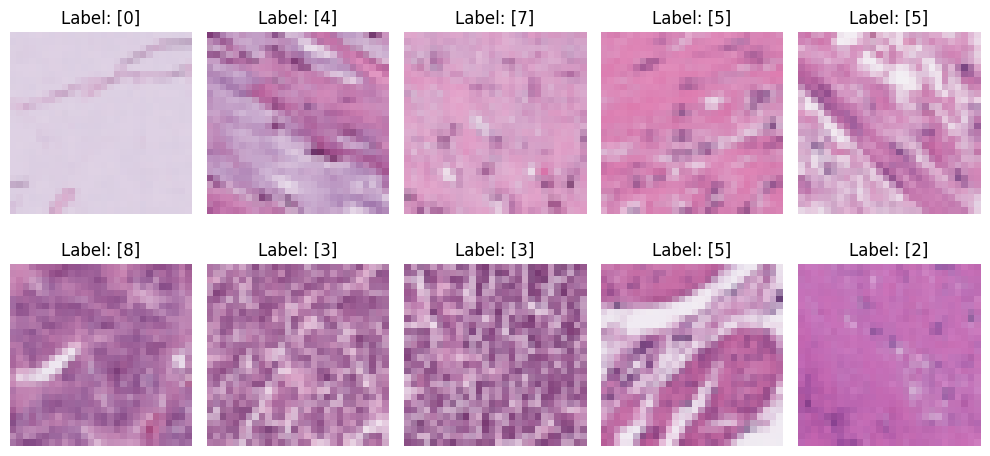

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    image = image.permute(1, 2, 0)  # (C,H,W) → (H,W,C)
    ax.imshow(image)
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()


# --- 3. Statistiques descriptives : Distribution des classes ---

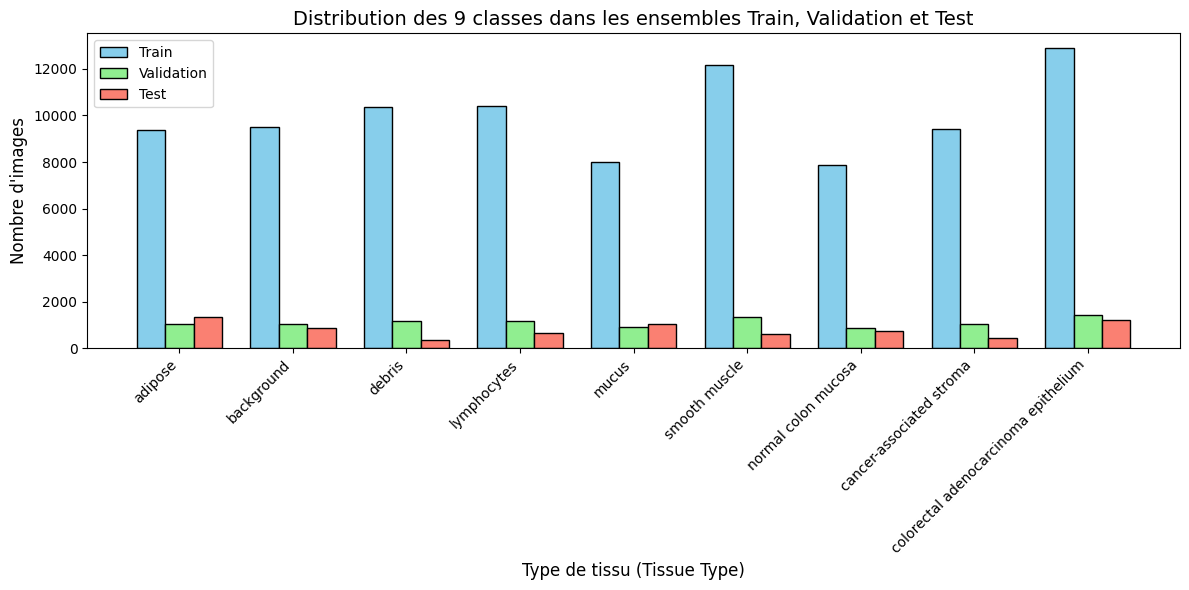

In [16]:
train_counts = np.bincount(train_dataset.labels.squeeze(), minlength=9)
val_counts = np.bincount(val_dataset.labels.squeeze(), minlength=9)
test_counts = np.bincount(test_dataset.labels.squeeze(), minlength=9)

classes_names = [class_dict[str(i)] for i in range(9)]

# Paramètres pour le graphique en barres groupées
x = np.arange(len(classes_names))
width = 0.25  # Largeur des barres

fig, ax = plt.subplots(figsize=(12, 6))
# Création des 3 séries de barres
rects1 = ax.bar(x - width, train_counts, width, label='Train', color='skyblue', edgecolor='black')
rects2 = ax.bar(x, val_counts, width, label='Validation', color='lightgreen', edgecolor='black')
rects3 = ax.bar(x + width, test_counts, width, label='Test', color='salmon', edgecolor='black')

# Ajout des titres et légendes obligatoires
ax.set_title("Distribution des 9 classes dans les ensembles Train, Validation et Test", fontsize=14)
ax.set_xlabel("Type de tissu (Tissue Type)", fontsize=12)
ax.set_ylabel("Nombre d'images", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(classes_names, rotation=45, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

# --- 1.1 : Visualisation Background vs Debris ---

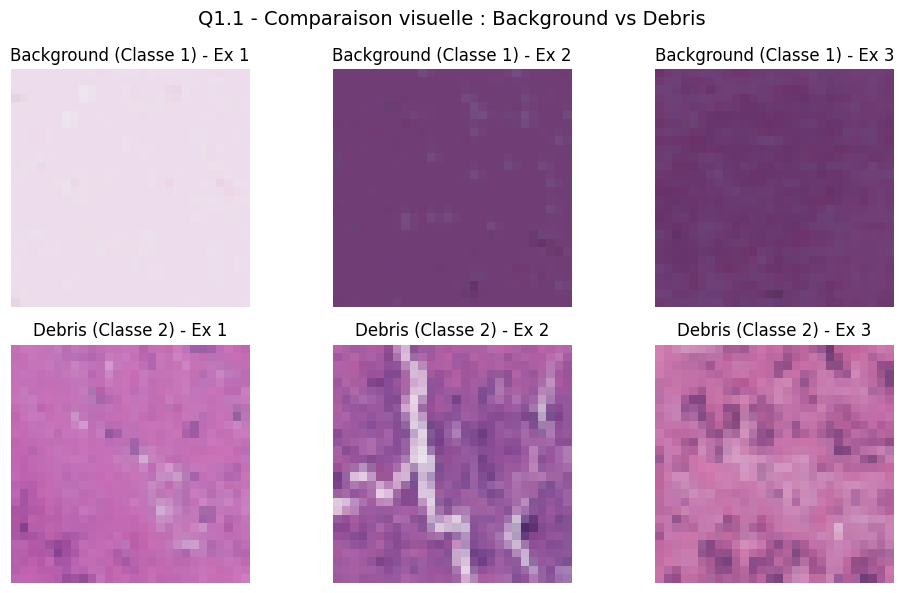

In [17]:
background_imgs = []
debris_imgs = []

# On parcourt le dataset d'entraînement pour récupérer quelques exemples
for img, label in train_dataset:
    lbl = label[0] if isinstance(label, (list, np.ndarray)) else label.item()
    
    if lbl == 1 and len(background_imgs) < 3:    # Classe 1 = Background
        background_imgs.append(img)
    elif lbl == 2 and len(debris_imgs) < 3:      # Classe 2 = Debris
        debris_imgs.append(img)
        
    if len(background_imgs) == 3 and len(debris_imgs) == 3:
        break

# Création de la figure 
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
fig.suptitle("Q1.1 - Comparaison visuelle : Background vs Debris", fontsize=14)

for i in range(3):
    # Affichage Background
    axes[0, i].imshow(background_imgs[i].permute(1, 2, 0)) # Conversion (C,H,W) vers (H,W,C)
    axes[0, i].set_title(f"Background (Classe 1) - Ex {i+1}")
    axes[0, i].axis('off')
    
    # Affichage Debris
    axes[1, i].imshow(debris_imgs[i].permute(1, 2, 0))
    axes[1, i].set_title(f"Debris (Classe 2) - Ex {i+1}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

### Analyse visuelle

Les images de la classe Background apparaissent globalement plus homogènes et uniformes, avec peu de structures visibles. Les couleurs sont souvent plus lisses et les variations de texture sont faibles.

À l’inverse, les images de la classe Debris présentent davantage d’irrégularités. On observe des textures plus complexes, avec des variations de couleurs plus marquées et des structures fragmentées.

Ainsi, la principale différence entre ces deux classes repose sur la texture : Background est plus uniforme tandis que Debris est plus hétérogène et riche en détails.


# --- 1.2 : Statistiques des pixels ---

In [18]:
# On prend une image au hasard du dataset d'entraînement
sample_img, sample_label = train_dataset[0]

# Calcul de la moyenne et de l'écart-type sur les dimensions spatiales (Hauteur=1, Largeur=2)
# Cela nous donne une valeur pour chaque canal (R, G, B)
mean_rgb = torch.mean(sample_img, dim=[1, 2])
std_rgb = torch.std(sample_img, dim=[1, 2])

print("\n--- Q1.2 : Statistiques d'intensité des pixels ---")
print(f"Classe de l'image analysée : {class_dict[str(sample_label.item())]}")
print(f"Moyenne par canal (R, G, B) : {mean_rgb.numpy()}")
print(f"Écart-type par canal (R, G, B) : {std_rgb.numpy()}")


--- Q1.2 : Statistiques d'intensité des pixels ---
Classe de l'image analysée : adipose
Moyenne par canal (R, G, B) : [0.8593537  0.8025361  0.88142747]
Écart-type par canal (R, G, B) : [0.01759462 0.03249656 0.02297844]


### 1. Exploration des données et Statistiques (Analyse)

**Compréhension globale du dataset :**
L'exploration initiale du dataset PathMNIST montre que nos données sont parfaitement équilibrées. Le graphique de distribution confirme que chacune des 9 classes contient un nombre similaire d'images (environ 10 000 par classe pour l'ensemble d'entraînement). Cette répartition équitable se retrouve également dans les ensembles de validation et de test. C'est une excellente caractéristique qui nous évitera de devoir appliquer des techniques de pondération complexes pour compenser un déséquilibre de classes lors de l'apprentissage.

**1.1 - Différences visuelles entre Background et Debris :**
L'observation visuelle des échantillons révèle des différences majeures entre ces deux classes, tant au niveau de la couleur que de la texture :
* **Couleur :** Les images de la classe *Background* (le fond de la lame) sont extrêmement claires, presque uniformément blanches ou gris très pâle. À l'inverse, la classe *Debris* présente des couleurs beaucoup plus prononcées avec des taches sombres aux teintes violettes, roses ou brunes, qui sont typiques des colorants utilisés en histologie.
* **Texture :** Le *Background* est totalement lisse, uniforme et dépourvu de structure. Les *Debris*, en revanche, ont une texture très chaotique et granuleuse, formée d'amas de cellules ou de tissus détruits dispersés de manière irrégulière.

**1.2 - Statistiques des pixels et comparaison avec ImageNet :**
L'analyse d'une image de l'ensemble d'entraînement (appartenant à la classe *Adipose*) donne les intensités de pixels suivantes :
* **Moyenne (R, G, B) :** [0.8593537, 0.8025361, 0.88142747]
* **Écart-type (R, G, B) :** [0.01759462, 0.03249656, 0.02297844]

Ces valeurs ne sont pas du tout proches des statistiques standards d'ImageNet (où la moyenne est d'environ [0.485, 0.456, 0.406] et l'écart-type d'environ [0.229, 0.224, 0.225]). 
Cette différence est logique : les images médicales d'histologie sont beaucoup plus lumineuses (fonds très blancs traversés par la lumière du microscope), ce qui explique une moyenne très élevée, proche de 1. De plus, la variance des couleurs est très faible (petit écart-type) car l'image est dominée par des teintes assez uniformes (le blanc du fond et les colorants roses/violets), contrairement aux photographies naturelles d'ImageNet qui contiennent une très grande variété de couleurs et de forts contrastes.

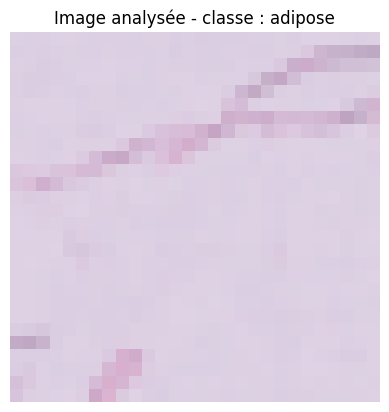

In [19]:
plt.imshow(sample_img.permute(1,2,0))
plt.title(f"Image analysée - classe : {class_dict[str(sample_label.item())]}")
plt.axis("off")
plt.show()
